# AI-Powered Student Risk & Employability Predictor
## 8. Modelling

This notebook is a direct continuation of the EDA notebook.  
All four datasets are already preprocessed, scaled, encoded, and (where needed) SMOTE-balanced.  
We load those ready-made files, train classification models, evaluate them, and save the best performers.

---

## 8.0 Imports & Global Configuration

In [1]:
! pip install --upgrade shap


In [2]:
%pip install xgboost 

Note: you may need to restart the kernel to use updated packages.


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib, os


from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, f1_score)
from xgboost import XGBClassifier

# ── global style (matching EDA notebook) ──────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
})
PALETTE = ['#378ADD', '#D85A30', '#1D9E75', '#EF9F27', '#7F77DD', '#D4537E']

os.makedirs('models',  exist_ok=True)
os.makedirs('outputs', exist_ok=True)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 8.1 Load Preprocessed Datasets

All files were saved at the end of the EDA notebook after SMOTE balancing, scaling, and encoding.

In [4]:
df_dropout  = pd.read_csv('../data/df_dropout_preprocessed.csv')
df_academic = pd.read_csv('../data/df_academic_preprocessed.csv')
df_employ   = pd.read_csv('../data/df_employ_preprocessed.csv')
df_resume   = pd.read_csv('../data/df_resume_preprocessed.csv')

print("Dropout  shape:", df_dropout.shape)
print("Academic shape:", df_academic.shape)
print("Employ   shape:", df_employ.shape)
print("Resume   shape:", df_resume.shape)

Dropout  shape: (6627, 7)
Academic shape: (23940, 6)
Employ   shape: (620, 31)
Resume   shape: (2836, 13)


## 8.2 Helper Functions

Shared utilities for training, evaluating, and plotting results.

In [5]:
def evaluate_model(model, X_test, y_test, model_name, class_names=None):
    """Print classification report and return key metrics dict."""
    y_pred = model.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}   |   Weighted F1 : {f1:.4f}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=class_names))
    return {'model': model_name, 'accuracy': acc, 'f1_weighted': f1,
            'y_test': y_test, 'y_pred': y_pred}


def plot_confusion(results, class_names, title, fname):
    """Confusion matrices for a list of result dicts."""
    n = len(results)
    num_classes = len(class_names)
    
    if num_classes > 10:
        # HUGE MATRICES (Resume NLP) - Stack vertically to prevent Jupyter from shrinking them
        fig, axes = plt.subplots(n, 1, figsize=(14, 12 * n))
        if n == 1: axes = [axes]
        
        for ax, res in zip(axes, results):
            cm = confusion_matrix(res['y_test'], res['y_pred'])
            disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
            # Normal font sizes, rotated text
            disp.plot(ax=ax, colorbar=False, cmap='Blues', 
                      xticks_rotation='vertical', text_kw={'fontsize': 10}) 
            ax.set_title(res['model'], fontsize=16, fontweight='bold', pad=15)
            ax.tick_params(axis='both', which='major', labelsize=10)
            
    else:
        # SMALL MATRICES (Dropout, Academic, etc) - Keep side-by-side
        fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
        if n == 1: axes = [axes]
        
        for ax, res in zip(axes, results):
            cm = confusion_matrix(res['y_test'], res['y_pred'])
            disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
            disp.plot(ax=ax, colorbar=False, cmap='Blues')
            ax.set_title(res['model'], fontsize=12)
            
    # Adjust title position based on layout
    y_pos = 1.02 if num_classes <= 10 else 1.0 
    fig.suptitle(title, fontsize=18, fontweight='bold', y=y_pos)
    
    plt.tight_layout()
    plt.savefig(f'outputs/{fname}', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → outputs/{fname}")



def plot_feature_importance(model, feature_names, title, fname, top_n=10):
    """Horizontal bar chart of feature importances."""
    if not hasattr(model, 'feature_importances_'):
        print(f"  {title}: model has no feature_importances_ attribute — skipping.")
        return
    imp = pd.Series(model.feature_importances_, index=feature_names).nlargest(top_n)
    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(imp.index[::-1], imp.values[::-1], color=PALETTE[0], height=0.55, edgecolor='none')
    for bar, val in zip(bars, imp.values[::-1]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9, color='#444')
    ax.set_xlabel('Feature Importance')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f'outputs/{fname}', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → outputs/{fname}")


def summarise(results_list):
    """Print a tidy comparison table for a group of models."""
    df = pd.DataFrame([{k: v for k, v in r.items()
                        if k not in ('y_test', 'y_pred')}
                       for r in results_list])
    df = df.sort_values('f1_weighted', ascending=False).reset_index(drop=True)
    print(df.to_string(index=False))
    return df

print("✓ Helper functions defined")

✓ Helper functions defined


---
## 9. Dropout Prediction

**Task**: Multiclass classification — Graduate (2) | Enrolled (1) | Dropout (0)  
**Dataset**: SMOTE-balanced, features scaled in the EDA notebook.

In [6]:
# ── Dropout: define X and y ───────────────────────────────────────────────────
DROPOUT_FEATURES = ['age_at_enrollment', 'admission_grade',
                    'total_units_approved', 'scholarship_holder', 'debtor']
DROPOUT_TARGET   = 'target'
DROPOUT_CLASSES  = ['Dropout', 'Enrolled', 'Graduate']   # label-encoded 0,1,2

X_drop = df_dropout[DROPOUT_FEATURES]
y_drop = df_dropout[DROPOUT_TARGET]

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_drop, y_drop, test_size=0.2, random_state=RANDOM_SEED, stratify=y_drop)

print(f"Train: {X_train_d.shape}  |  Test: {X_test_d.shape}")
print("Class distribution (train):", dict(zip(*np.unique(y_train_d, return_counts=True))))

Train: (5301, 5)  |  Test: (1326, 5)
Class distribution (train): {0: 1767, 1: 1767, 2: 1767}


### 9.1 Random Forest — Dropout

In [7]:
rf_drop = RandomForestClassifier(n_estimators=200, max_depth=10,
                                  random_state=RANDOM_SEED, n_jobs=-1)
rf_drop.fit(X_train_d, y_train_d)

res_rf_drop = evaluate_model(rf_drop, X_test_d, y_test_d,
                              'Random Forest — Dropout', DROPOUT_CLASSES)


  Random Forest — Dropout
  Accuracy : 0.7323   |   Weighted F1 : 0.7325
              precision    recall  f1-score   support

     Dropout       0.81      0.69      0.75       442
    Enrolled       0.67      0.70      0.69       442
    Graduate       0.73      0.80      0.76       442

    accuracy                           0.73      1326
   macro avg       0.74      0.73      0.73      1326
weighted avg       0.74      0.73      0.73      1326



### 9.2 XGBoost — Dropout

In [8]:
xgb_drop = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                          use_label_encoder=False, eval_metric='mlogloss',
                          random_state=RANDOM_SEED, n_jobs=-1)
xgb_drop.fit(X_train_d, y_train_d)

res_xgb_drop = evaluate_model(xgb_drop, X_test_d, y_test_d,
                               'XGBoost — Dropout', DROPOUT_CLASSES)


  XGBoost — Dropout
  Accuracy : 0.7345   |   Weighted F1 : 0.7336
              precision    recall  f1-score   support

     Dropout       0.79      0.68      0.73       442
    Enrolled       0.69      0.69      0.69       442
    Graduate       0.74      0.83      0.78       442

    accuracy                           0.73      1326
   macro avg       0.74      0.73      0.73      1326
weighted avg       0.74      0.73      0.73      1326



### 9.3 Results Comparison & Confusion Matrices — Dropout


--- Dropout Model Comparison ---
                  model  accuracy  f1_weighted
      XGBoost — Dropout  0.734540     0.733585
Random Forest — Dropout  0.732278     0.732457


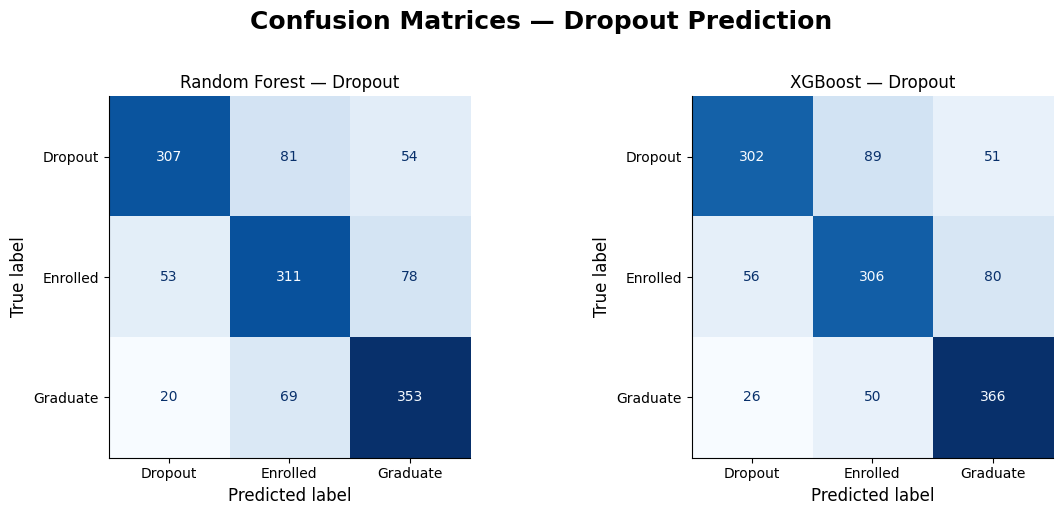

Saved → outputs/model1_dropout_cm.png


In [9]:
drop_results = [res_rf_drop, res_xgb_drop]
print("\n--- Dropout Model Comparison ---")
drop_summary = summarise(drop_results)

plot_confusion(drop_results, DROPOUT_CLASSES,
               'Confusion Matrices — Dropout Prediction',
               'model1_dropout_cm.png')

### 9.4 Feature Importance — Dropout (Best Model)

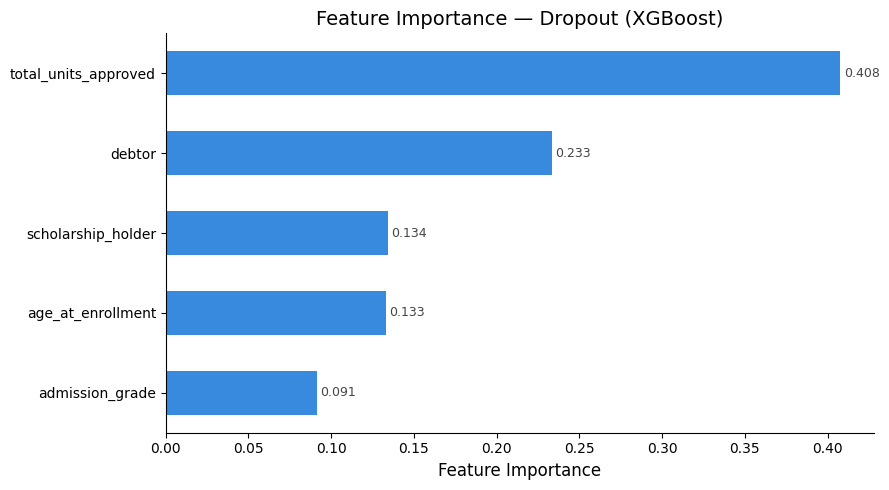

Saved → outputs/model1_dropout_feature_imp.png


In [10]:
best_drop = rf_drop if res_rf_drop['f1_weighted'] >= res_xgb_drop['f1_weighted'] else xgb_drop
best_drop_name = 'Random Forest' if best_drop is rf_drop else 'XGBoost'

plot_feature_importance(best_drop, DROPOUT_FEATURES,
                        f'Feature Importance — Dropout ({best_drop_name})',
                        'model1_dropout_feature_imp.png')

---
## 10. Academic Risk Prediction

**Task**: Multiclass classification — At Risk (0) | Average (1) | High Performance (2)  
**Dataset**: SMOTE-balanced, features scaled.

In [11]:
ACADEMIC_FEATURES = ['gpa', 'absences', 'hours_studied',
                      'engagement_score', 'study_efficiency']
ACADEMIC_TARGET   = 'target_encoded'
ACADEMIC_CLASSES  = ['At Risk', 'Average', 'High Performance']

X_acad = df_academic[ACADEMIC_FEATURES]
y_acad = df_academic[ACADEMIC_TARGET]

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_acad, y_acad, test_size=0.2, random_state=RANDOM_SEED, stratify=y_acad)

print(f"Train: {X_train_a.shape}  |  Test: {X_test_a.shape}")
print("Class distribution (train):", dict(zip(*np.unique(y_train_a, return_counts=True))))

Train: (19152, 5)  |  Test: (4788, 5)
Class distribution (train): {0: 6384, 1: 6384, 2: 6384}


### 10.1 Random Forest — Academic Risk

In [12]:
rf_acad = RandomForestClassifier(n_estimators=200, max_depth=10,
                                   random_state=RANDOM_SEED, n_jobs=-1)
rf_acad.fit(X_train_a, y_train_a)

res_rf_acad = evaluate_model(rf_acad, X_test_a, y_test_a,
                              'Random Forest — Academic Risk', ACADEMIC_CLASSES)


  Random Forest — Academic Risk
  Accuracy : 0.8939   |   Weighted F1 : 0.8953
                  precision    recall  f1-score   support

         At Risk       1.00      0.86      0.92      1596
         Average       0.91      0.88      0.90      1596
High Performance       0.81      0.94      0.87      1596

        accuracy                           0.89      4788
       macro avg       0.90      0.89      0.90      4788
    weighted avg       0.90      0.89      0.90      4788



### 10.2 XGBoost — Academic Risk

In [13]:
xgb_acad = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                          use_label_encoder=False, eval_metric='mlogloss',
                          random_state=RANDOM_SEED, n_jobs=-1)
xgb_acad.fit(X_train_a, y_train_a)

res_xgb_acad = evaluate_model(xgb_acad, X_test_a, y_test_a,
                               'XGBoost — Academic Risk', ACADEMIC_CLASSES)


  XGBoost — Academic Risk
  Accuracy : 0.8876   |   Weighted F1 : 0.8891
                  precision    recall  f1-score   support

         At Risk       1.00      0.85      0.92      1596
         Average       0.90      0.87      0.89      1596
High Performance       0.80      0.94      0.86      1596

        accuracy                           0.89      4788
       macro avg       0.90      0.89      0.89      4788
    weighted avg       0.90      0.89      0.89      4788



### 10.3 Results Comparison & Confusion Matrices — Academic Risk


--- Academic Risk Model Comparison ---
                        model  accuracy  f1_weighted
Random Forest — Academic Risk  0.893901     0.895278
      XGBoost — Academic Risk  0.887636     0.889124


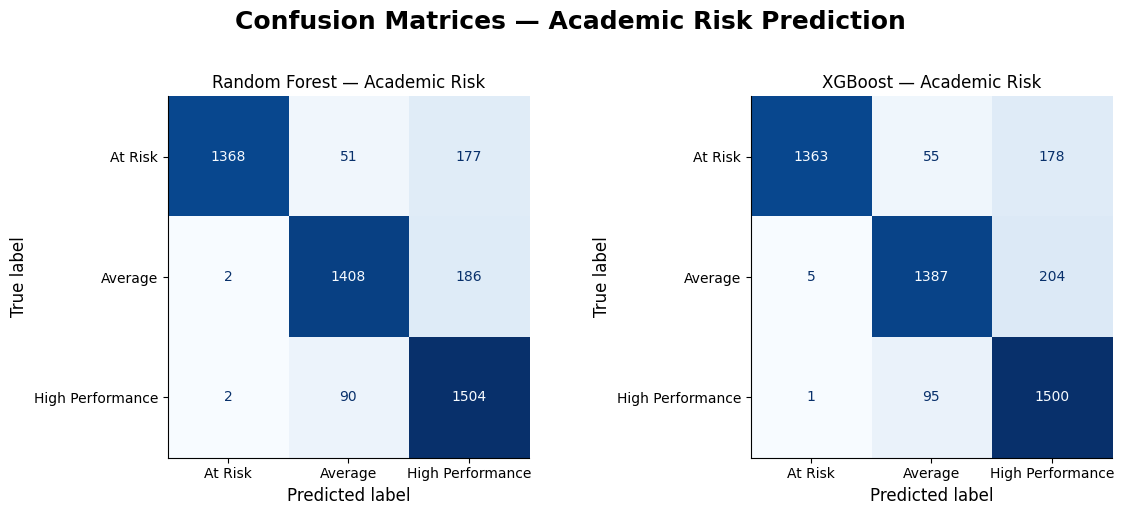

Saved → outputs/model2_academic_cm.png


In [14]:
acad_results = [res_rf_acad, res_xgb_acad]
print("\n--- Academic Risk Model Comparison ---")
acad_summary = summarise(acad_results)

plot_confusion(acad_results, ACADEMIC_CLASSES,
               'Confusion Matrices — Academic Risk Prediction',
               'model2_academic_cm.png')

### 10.4 Feature Importance — Academic Risk

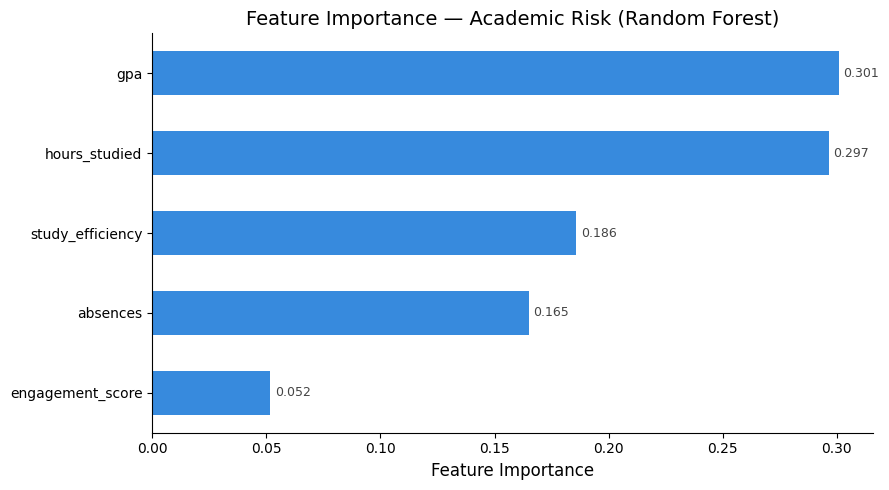

Saved → outputs/model2_academic_feature_imp.png


In [15]:
best_acad = rf_acad if res_rf_acad['f1_weighted'] >= res_xgb_acad['f1_weighted'] else xgb_acad
best_acad_name = 'Random Forest' if best_acad is rf_acad else 'XGBoost'

plot_feature_importance(best_acad, ACADEMIC_FEATURES,
                        f'Feature Importance — Academic Risk ({best_acad_name})',
                        'model2_academic_feature_imp.png')

---
## 11. Employability Prediction

**Task**: Multiclass classification — Low Readiness (0) | Medium Readiness (1) | High Readiness (2)  
**Dataset**: Already class-balanced (no SMOTE needed), features scaled.

In [16]:
EMPLOY_FEATURES = ['gpa', 'tech_score_avg', 'soft_score_avg', 'career_score_avg']
EMPLOY_TARGET   = 'readiness_encoded'
EMPLOY_CLASSES  = ['Low Readiness', 'Medium Readiness', 'High Readiness']

X_emp = df_employ[EMPLOY_FEATURES]
y_emp = df_employ[EMPLOY_TARGET]

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_emp, y_emp, test_size=0.2, random_state=RANDOM_SEED, stratify=y_emp)

print(f"Train: {X_train_e.shape}  |  Test: {X_test_e.shape}")
print("Class distribution (train):", dict(zip(*np.unique(y_train_e, return_counts=True))))

Train: (496, 4)  |  Test: (124, 4)
Class distribution (train): {0: 169, 1: 165, 2: 162}


### 11.1 Random Forest — Employability

In [17]:
rf_emp = RandomForestClassifier(n_estimators=200, max_depth=10,
                                 random_state=RANDOM_SEED, n_jobs=-1)
rf_emp.fit(X_train_e, y_train_e)

res_rf_emp = evaluate_model(rf_emp, X_test_e, y_test_e,
                             'Random Forest — Employability', EMPLOY_CLASSES)


  Random Forest — Employability
  Accuracy : 0.5323   |   Weighted F1 : 0.5320
                  precision    recall  f1-score   support

   Low Readiness       0.58      0.69      0.63        42
Medium Readiness       0.70      0.56      0.62        41
  High Readiness       0.34      0.34      0.34        41

        accuracy                           0.53       124
       macro avg       0.54      0.53      0.53       124
    weighted avg       0.54      0.53      0.53       124



### 11.2 XGBoost — Employability

In [18]:
xgb_emp = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                         use_label_encoder=False, eval_metric='mlogloss',
                         random_state=RANDOM_SEED, n_jobs=-1)
xgb_emp.fit(X_train_e, y_train_e)

res_xgb_emp = evaluate_model(xgb_emp, X_test_e, y_test_e,
                              'XGBoost — Employability', EMPLOY_CLASSES)


  XGBoost — Employability
  Accuracy : 0.4758   |   Weighted F1 : 0.4776
                  precision    recall  f1-score   support

   Low Readiness       0.57      0.64      0.61        42
Medium Readiness       0.61      0.49      0.54        41
  High Readiness       0.27      0.29      0.28        41

        accuracy                           0.48       124
       macro avg       0.48      0.47      0.48       124
    weighted avg       0.49      0.48      0.48       124



### 11.3 Results Comparison & Confusion Matrices — Employability


--- Employability Model Comparison ---
                        model  accuracy  f1_weighted
Random Forest — Employability  0.532258     0.531974
      XGBoost — Employability  0.475806     0.477595


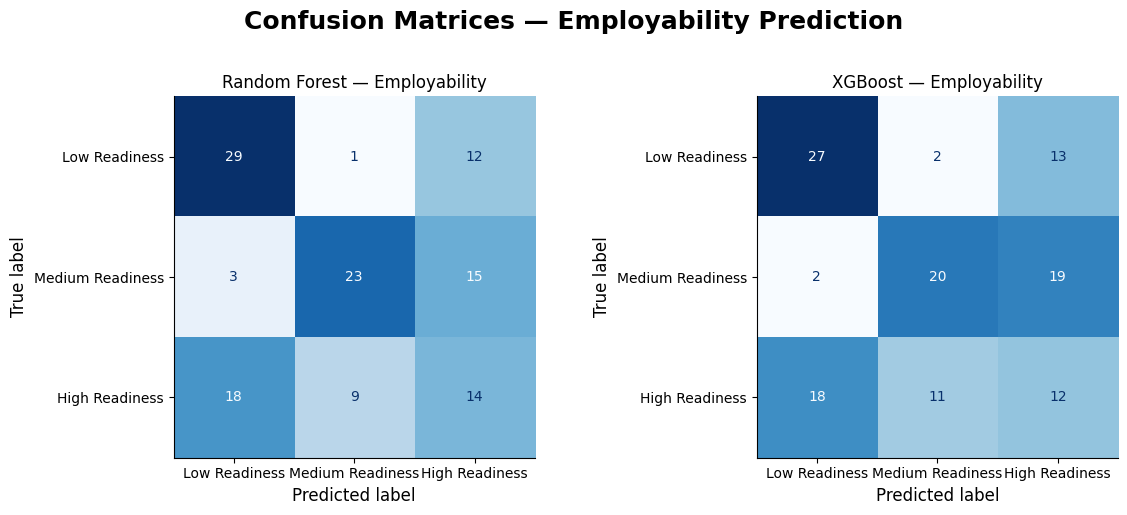

Saved → outputs/model3_employ_cm.png


In [19]:
emp_results = [res_rf_emp, res_xgb_emp]
print("\n--- Employability Model Comparison ---")
emp_summary = summarise(emp_results)

plot_confusion(emp_results, EMPLOY_CLASSES,
               'Confusion Matrices — Employability Prediction',
               'model3_employ_cm.png')

### 11.4 Feature Importance — Employability

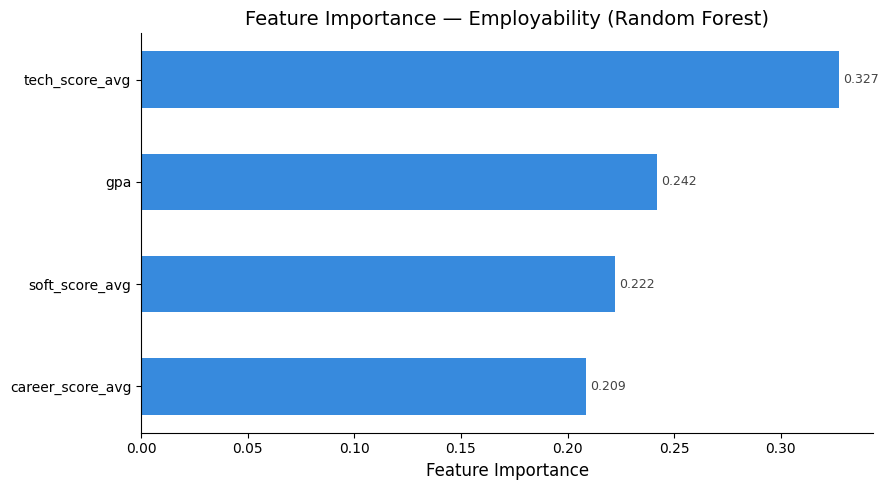

Saved → outputs/model3_employ_feature_imp.png


In [20]:
best_emp = rf_emp if res_rf_emp['f1_weighted'] >= res_xgb_emp['f1_weighted'] else xgb_emp
best_emp_name = 'Random Forest' if best_emp is rf_emp else 'XGBoost'

plot_feature_importance(best_emp, EMPLOY_FEATURES,
                        f'Feature Importance — Employability ({best_emp_name})',
                        'model3_employ_feature_imp.png')

---
## 12. Resume NLP Classification

**Task**: Multiclass classification — predict job category from TF-IDF SVD topic features.  
**Dataset**: 10 LSA topic components + `has_experience` flag.

In [21]:
RESUME_FEATURES = [f'topic_{i}' for i in range(10)] + ['has_experience']
RESUME_TARGET   = 'category_encoded'

# Recover original category labels for display
category_labels = df_resume['category'].unique()
le_map = {i: cat for i, cat in enumerate(sorted(category_labels))}
RESUME_CLASSES  = [le_map[i] for i in sorted(le_map.keys())]

X_res = df_resume[RESUME_FEATURES]
y_res = df_resume[RESUME_TARGET]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_res, y_res, test_size=0.2, random_state=RANDOM_SEED, stratify=y_res)

print(f"Train: {X_train_r.shape}  |  Test: {X_test_r.shape}")
print(f"Unique categories: {y_res.nunique()}")

Train: (2268, 11)  |  Test: (568, 11)
Unique categories: 55


### 12.1 Logistic Regression — Resume NLP

In [22]:
lr_res = LogisticRegression(max_iter=1000, C=1.0,
                            random_state=RANDOM_SEED, n_jobs=-1)
lr_res.fit(X_train_r, y_train_r)

res_lr_res = evaluate_model(lr_res, X_test_r, y_test_r,
                             'Logistic Regression — Resume NLP', RESUME_CLASSES)


  Logistic Regression — Resume NLP
  Accuracy : 0.4225   |   Weighted F1 : 0.3760
                                    precision    recall  f1-score   support

                        ACCOUNTANT       0.53      0.79      0.63        24
                          ADVOCATE       0.17      0.21      0.19        24
                       AGRICULTURE       0.00      0.00      0.00        13
                           APPAREL       0.20      0.05      0.08        19
                              ARTS       0.18      0.10      0.12        21
                        AUTOMOBILE       0.00      0.00      0.00         7
                          AVIATION       0.67      0.70      0.68        23
                          Advocate       0.00      0.00      0.00         2
                              Arts       0.00      0.00      0.00         1
                Automation Testing       0.00      0.00      0.00         1
                           BANKING       0.35      0.26      0.30        23
    

### 12.2 Random Forest — Resume NLP

In [23]:
rf_res = RandomForestClassifier(n_estimators=200, max_depth=15,
                                 random_state=RANDOM_SEED, n_jobs=-1)
rf_res.fit(X_train_r, y_train_r)

res_rf_res = evaluate_model(rf_res, X_test_r, y_test_r,
                             'Random Forest — Resume NLP', RESUME_CLASSES)


  Random Forest — Resume NLP
  Accuracy : 0.5123   |   Weighted F1 : 0.4922
                                    precision    recall  f1-score   support

                        ACCOUNTANT       0.63      0.71      0.67        24
                          ADVOCATE       0.24      0.33      0.28        24
                       AGRICULTURE       0.30      0.23      0.26        13
                           APPAREL       0.50      0.32      0.39        19
                              ARTS       0.00      0.00      0.00        21
                        AUTOMOBILE       0.00      0.00      0.00         7
                          AVIATION       0.57      0.70      0.63        23
                          Advocate       1.00      1.00      1.00         2
                              Arts       1.00      1.00      1.00         1
                Automation Testing       1.00      1.00      1.00         1
                           BANKING       0.31      0.48      0.38        23
          

### 12.3 Results Comparison & Confusion Matrices — Resume NLP


--- Resume NLP Model Comparison ---
                           model  accuracy  f1_weighted
      Random Forest — Resume NLP  0.512324     0.492178
Logistic Regression — Resume NLP  0.422535     0.375967


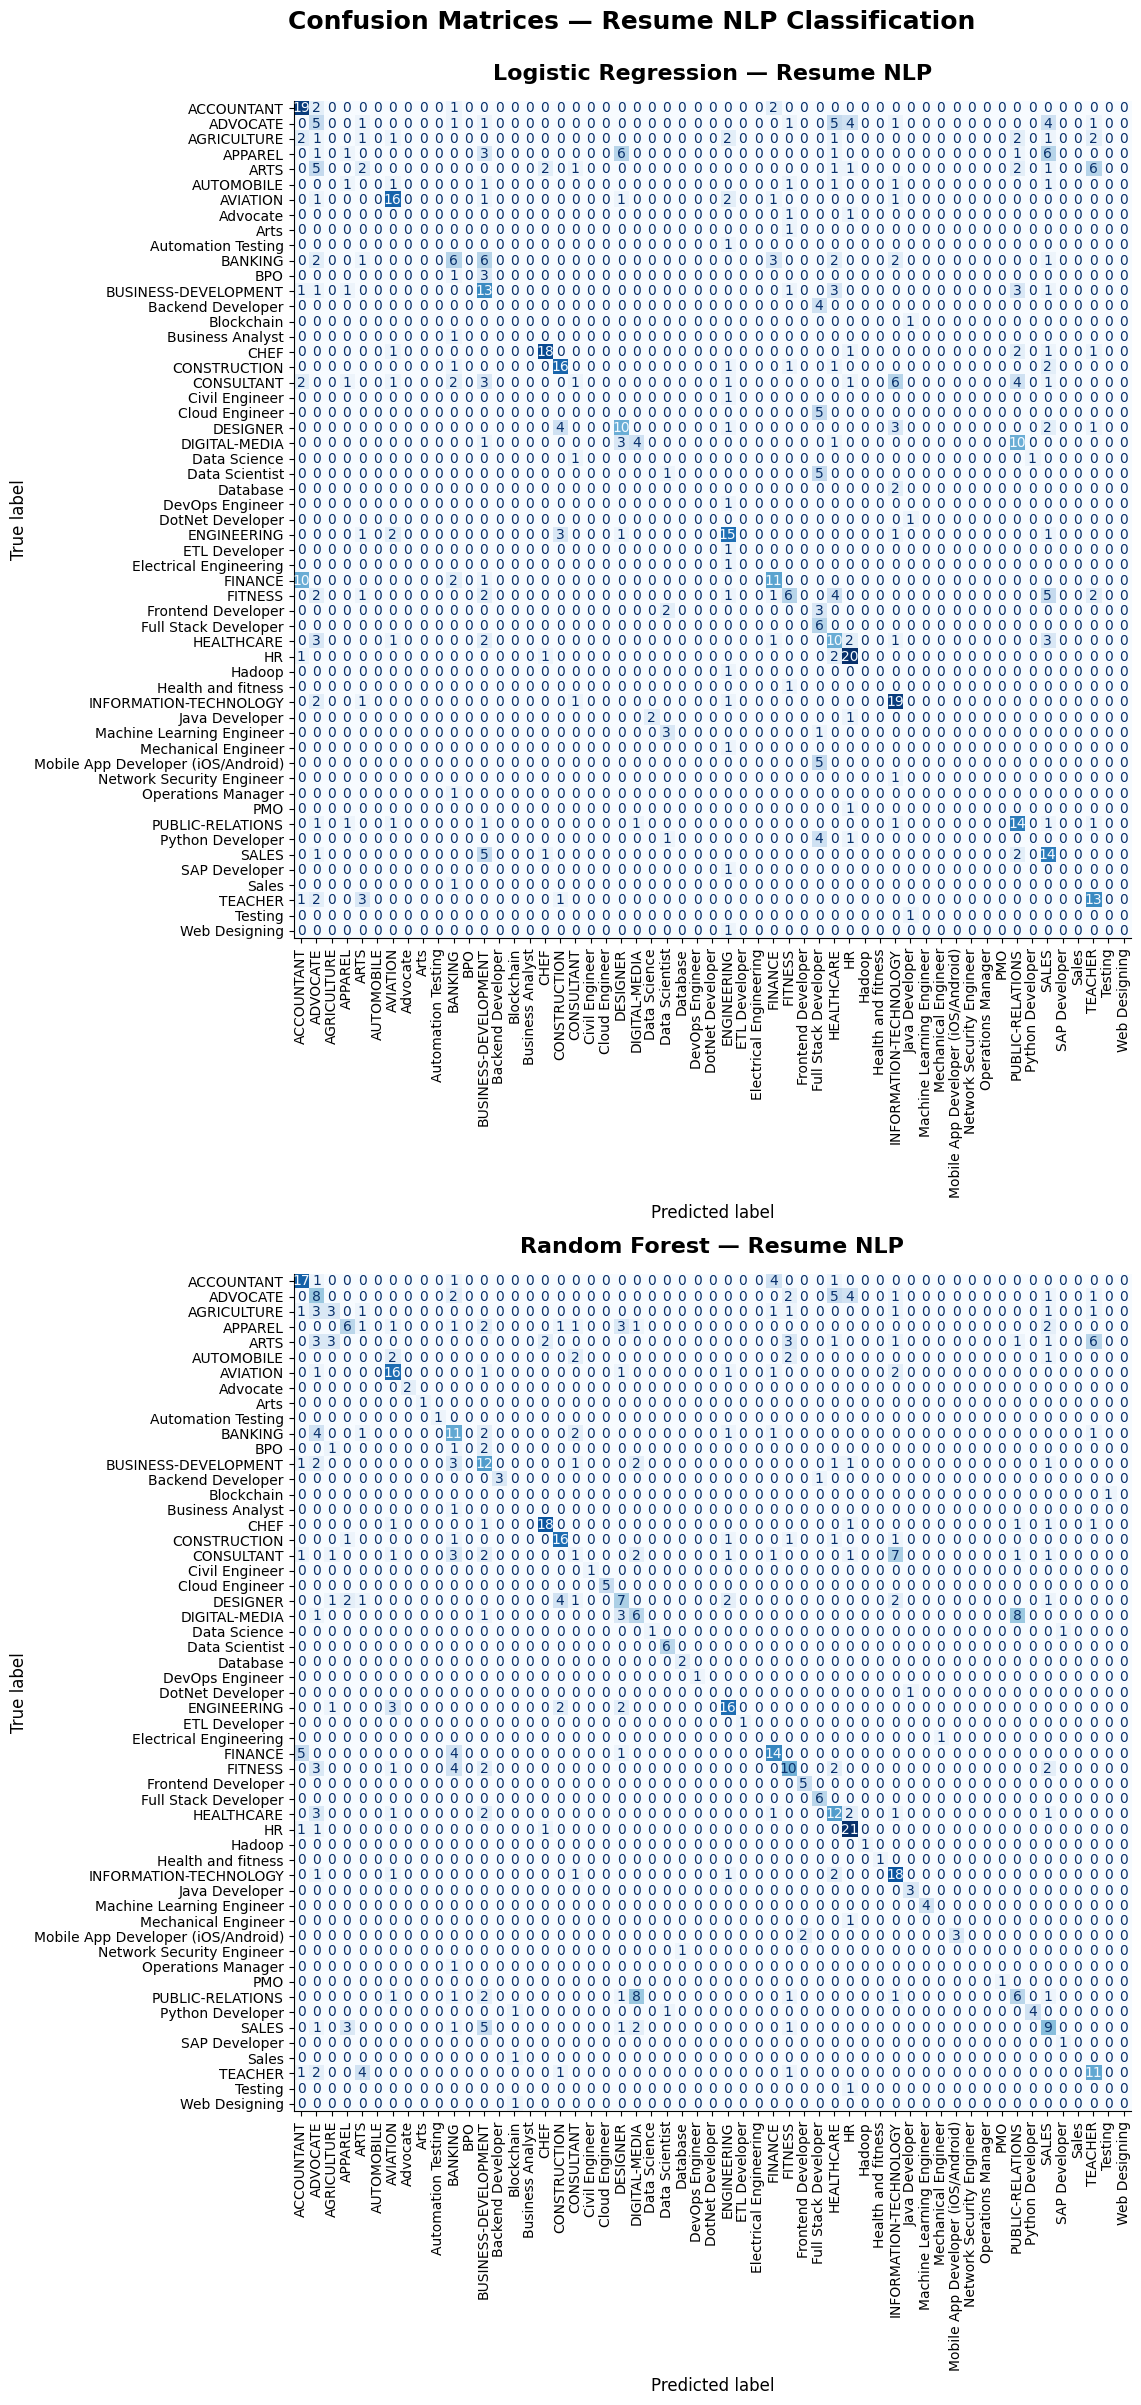

Saved → outputs/model4_resume_cm.png


In [24]:
res_results = [res_lr_res, res_rf_res]
print("\n--- Resume NLP Model Comparison ---")
res_summary = summarise(res_results)

plot_confusion(res_results, RESUME_CLASSES,
               'Confusion Matrices — Resume NLP Classification',
               'model4_resume_cm.png')

### 12.4 Feature Importance — Resume NLP

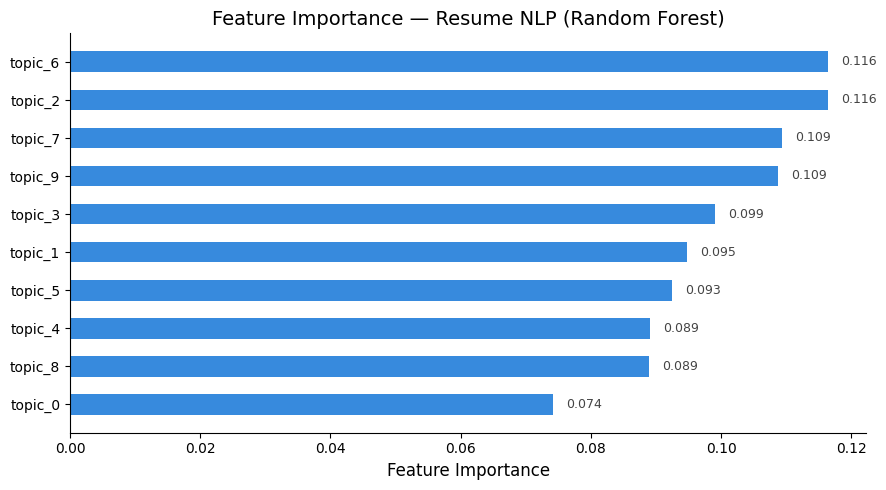

Saved → outputs/model4_resume_feature_imp.png


In [25]:
plot_feature_importance(rf_res, RESUME_FEATURES,
                        'Feature Importance — Resume NLP (Random Forest)',
                        'model4_resume_feature_imp.png')

---
## 13. Overall Model Summary

Comparing the best model from each domain.


========== OVERALL BEST MODEL SUMMARY ==========
       Domain                    Best Model  Accuracy  F1 (weighted)
      Dropout             XGBoost — Dropout    0.7345         0.7336
Academic Risk Random Forest — Academic Risk    0.8939         0.8953
Employability Random Forest — Employability    0.5323         0.5320
   Resume NLP    Random Forest — Resume NLP    0.5123         0.4922


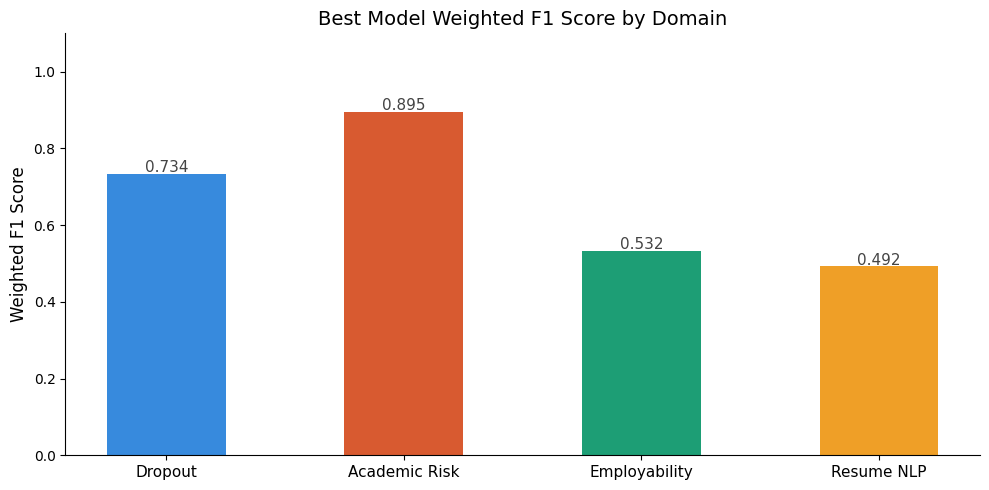

Saved → outputs/model_summary_f1.png


In [26]:
summary_rows = []
for domain, results in [
    ('Dropout',        drop_results),
    ('Academic Risk',  acad_results),
    ('Employability',  emp_results),
    ('Resume NLP',     res_results),
]:
    best = max(results, key=lambda r: r['f1_weighted'])
    summary_rows.append({
        'Domain':      domain,
        'Best Model':  best['model'],
        'Accuracy':    round(best['accuracy'], 4),
        'F1 (weighted)': round(best['f1_weighted'], 4),
    })

overall = pd.DataFrame(summary_rows)
print("\n========== OVERALL BEST MODEL SUMMARY ==========")
print(overall.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(overall))
bars = ax.bar(x, overall['F1 (weighted)'], color=PALETTE[:len(overall)],
              width=0.5, edgecolor='none')
for bar, val in zip(bars, overall['F1 (weighted)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=11, color='#444')
ax.set_xticks(x)
ax.set_xticklabels(overall['Domain'], fontsize=11)
ax.set_ylabel('Weighted F1 Score')
ax.set_title('Best Model Weighted F1 Score by Domain', fontsize=14)
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('outputs/model_summary_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → outputs/model_summary_f1.png")

---
## 14. Save Best Models

Save the best-performing model from each domain for future use in deployment (e.g., Streamlit app).

In [27]:
models_to_save = {
    'dropout_best_model.pkl':    best_drop,
    'academic_best_model.pkl':   best_acad,
    'employ_best_model.pkl':     best_emp,
    'resume_best_model.pkl':     (rf_res if res_rf_res['f1_weighted'] >= res_lr_res['f1_weighted'] else lr_res),
}

for fname, model in models_to_save.items():
    path = f'../models/{fname}'
    joblib.dump(model, path)
    print(f"✅ Saved: {path}")

print("\n✓ All best models saved to ../models/")

✅ Saved: ../models/dropout_best_model.pkl
✅ Saved: ../models/academic_best_model.pkl
✅ Saved: ../models/employ_best_model.pkl
✅ Saved: ../models/resume_best_model.pkl

✓ All best models saved to ../models/


---
## Summary

This notebook trained and evaluated classification models across all four student datasets:

| Domain | Models Tried | Key Metric |
|---|---|---|
| Dropout Prediction | Random Forest, XGBoost | Weighted F1 |
| Academic Risk | Random Forest, XGBoost | Weighted F1 |
| Employability | Random Forest, XGBoost | Weighted F1 |
| Resume NLP | Logistic Regression, Random Forest | Weighted F1 |

Best models have been saved to `../models/` for deployment.

## 15. Cross-Validation

Stratified K-Fold (5-fold) confirms that model scores are consistent across different data splits — not just a lucky train/test division.


In [28]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

cv_tasks = [
    ('Dropout',        best_drop,  X_drop,  y_drop),
    ('Academic Risk',  best_acad,  X_acad,  y_acad),
    ('Employability',  best_emp,   X_emp,   y_emp),
    ('Resume NLP',     rf_res,     X_res,   y_res),
]

cv_results = []
for name, model, X, y in cv_tasks:
    scores = cross_val_score(model, X, y, cv=cv, scoring='f1_weighted', n_jobs=-1)
    cv_results.append({
        'Domain': name,
        'Mean F1': round(scores.mean(), 4),
        'Std F1':  round(scores.std(),  4),
        'Min F1':  round(scores.min(),  4),
        'Max F1':  round(scores.max(),  4),
    })
    print(f"{name:15s}  Mean={scores.mean():.4f}  Std={scores.std():.4f}  [{scores.min():.4f} - {scores.max():.4f}]")

cv_df = pd.DataFrame(cv_results)
print("\n", cv_df.to_string(index=False))


Dropout          Mean=0.7430  Std=0.0065  [0.7345 - 0.7511]
Academic Risk    Mean=0.8954  Std=0.0028  [0.8930 - 0.9006]
Employability    Mean=0.6014  Std=0.0265  [0.5563 - 0.6341]
Resume NLP       Mean=0.4946  Std=0.0301  [0.4662 - 0.5490]

        Domain  Mean F1  Std F1  Min F1  Max F1
      Dropout   0.7430  0.0065  0.7345  0.7511
Academic Risk   0.8954  0.0028  0.8930  0.9006
Employability   0.6014  0.0265  0.5563  0.6341
   Resume NLP   0.4946  0.0301  0.4662  0.5490


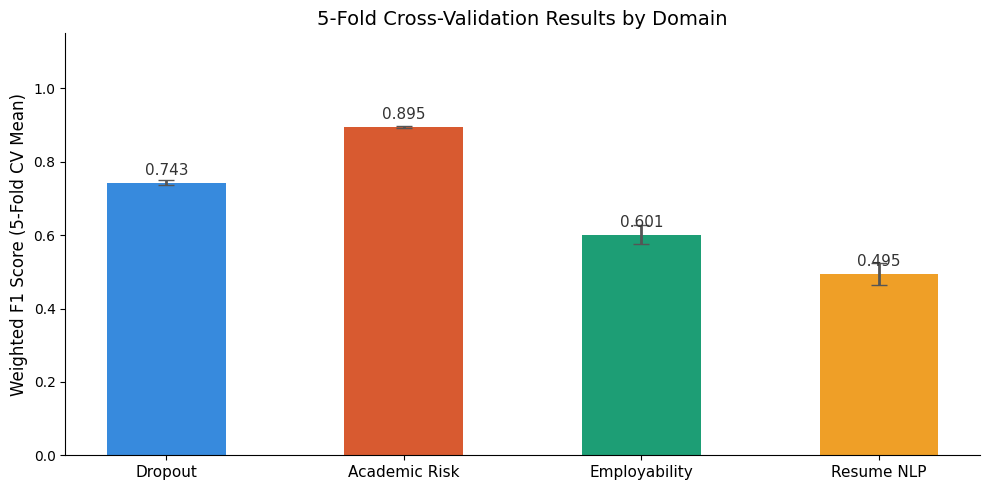

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(cv_df))
bars = ax.bar(x, cv_df['Mean F1'], yerr=cv_df['Std F1'],
              color=PALETTE[:len(cv_df)], width=0.5, edgecolor='none',
              capsize=6, error_kw={'elinewidth': 2, 'ecolor': '#555'})
for bar, val in zip(bars, cv_df['Mean F1']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontsize=11, color='#333')
ax.set_xticks(x)
ax.set_xticklabels(cv_df['Domain'], fontsize=11)
ax.set_ylabel('Weighted F1 Score (5-Fold CV Mean)')
ax.set_title('5-Fold Cross-Validation Results by Domain', fontsize=14)
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.savefig('outputs/cv_results.png', dpi=150, bbox_inches='tight')
plt.show()


## 16. Hyperparameter Tuning

RandomizedSearchCV (20 iterations, 5-fold) on the best model per domain.


In [30]:
#Define Grids 
from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [5, 8, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
}

param_dist_xgb = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [3, 5, 6, 8],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'subsample':         [0.7, 0.8, 1.0],
    'colsample_bytree':  [0.7, 0.8, 1.0],
}
print("Grids ready.")


Grids ready.


In [31]:
#Tune Dropout 
drop_base   = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1) if best_drop_name == 'Random Forest' else XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=RANDOM_SEED, n_jobs=-1)
drop_params = param_dist_rf if best_drop_name == 'Random Forest' else param_dist_xgb

rscv_drop = RandomizedSearchCV(drop_base, drop_params, n_iter=20, cv=5,
                                scoring='f1_weighted', random_state=RANDOM_SEED, n_jobs=-1)
rscv_drop.fit(X_train_d, y_train_d)
print("Best params:", rscv_drop.best_params_)
print(f"Best CV F1 : {rscv_drop.best_score_:.4f}")
res_tuned_drop = evaluate_model(rscv_drop.best_estimator_, X_test_d, y_test_d,
                                 f'Tuned {best_drop_name} — Dropout', DROPOUT_CLASSES)



Best params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Best CV F1 : 0.7390

  Tuned XGBoost — Dropout
  Accuracy : 0.7451   |   Weighted F1 : 0.7452
              precision    recall  f1-score   support

     Dropout       0.80      0.72      0.76       442
    Enrolled       0.70      0.72      0.71       442
    Graduate       0.74      0.80      0.77       442

    accuracy                           0.75      1326
   macro avg       0.75      0.75      0.75      1326
weighted avg       0.75      0.75      0.75      1326



In [32]:
#Tune Academic Risk 
acad_base   = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1) if best_acad_name == 'Random Forest' else XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=RANDOM_SEED, n_jobs=-1)
acad_params = param_dist_rf if best_acad_name == 'Random Forest' else param_dist_xgb

rscv_acad = RandomizedSearchCV(acad_base, acad_params, n_iter=20, cv=5,
                                scoring='f1_weighted', random_state=RANDOM_SEED, n_jobs=-1)
rscv_acad.fit(X_train_a, y_train_a)
print("Best params:", rscv_acad.best_params_)
print(f"Best CV F1 : {rscv_acad.best_score_:.4f}")
res_tuned_acad = evaluate_model(rscv_acad.best_estimator_, X_test_a, y_test_a,
                                 f'Tuned {best_acad_name} — Academic Risk', ACADEMIC_CLASSES)


Best params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Best CV F1 : 0.8957

  Tuned Random Forest — Academic Risk
  Accuracy : 0.8949   |   Weighted F1 : 0.8963
                  precision    recall  f1-score   support

         At Risk       1.00      0.86      0.92      1596
         Average       0.91      0.88      0.90      1596
High Performance       0.81      0.94      0.87      1596

        accuracy                           0.89      4788
       macro avg       0.90      0.89      0.90      4788
    weighted avg       0.90      0.89      0.90      4788



In [33]:
#Tune Employability
emp_base   = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1) if best_emp_name == 'Random Forest' else XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=RANDOM_SEED, n_jobs=-1)
emp_params = param_dist_rf if best_emp_name == 'Random Forest' else param_dist_xgb

rscv_emp = RandomizedSearchCV(emp_base, emp_params, n_iter=20, cv=5,
                               scoring='f1_weighted', random_state=RANDOM_SEED, n_jobs=-1)
rscv_emp.fit(X_train_e, y_train_e)
print("Best params:", rscv_emp.best_params_)
print(f"Best CV F1 : {rscv_emp.best_score_:.4f}")
res_tuned_emp = evaluate_model(rscv_emp.best_estimator_, X_test_e, y_test_e,
                                f'Tuned {best_emp_name} — Employability', EMPLOY_CLASSES)


Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Best CV F1 : 0.6096

  Tuned Random Forest — Employability
  Accuracy : 0.5323   |   Weighted F1 : 0.5308
                  precision    recall  f1-score   support

   Low Readiness       0.59      0.69      0.64        42
Medium Readiness       0.69      0.59      0.63        41
  High Readiness       0.33      0.32      0.32        41

        accuracy                           0.53       124
       macro avg       0.53      0.53      0.53       124
    weighted avg       0.53      0.53      0.53       124



       Domain   Before    After  Improvement
      Dropout 0.733585 0.745211       0.0116
Academic Risk 0.895278 0.896297       0.0010
Employability 0.531974 0.530842      -0.0011


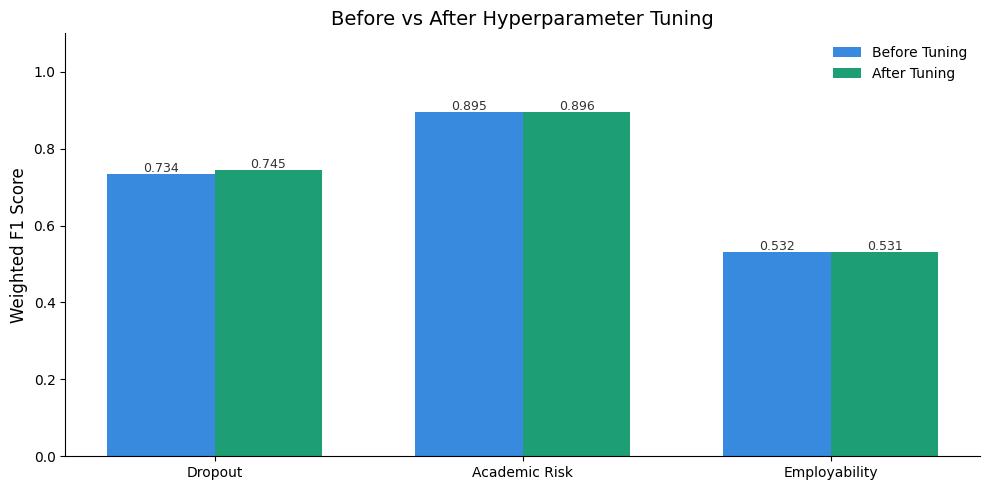

Tuned models saved to ../models/


In [34]:
#Before Vs After chart + save tuned models
tuning_comparison = pd.DataFrame([
    {'Domain': 'Dropout',       'Before': max(res_rf_drop['f1_weighted'], res_xgb_drop['f1_weighted']),  'After': res_tuned_drop['f1_weighted']},
    {'Domain': 'Academic Risk', 'Before': max(res_rf_acad['f1_weighted'], res_xgb_acad['f1_weighted']),  'After': res_tuned_acad['f1_weighted']},
    {'Domain': 'Employability', 'Before': max(res_rf_emp['f1_weighted'],  res_xgb_emp['f1_weighted']),   'After': res_tuned_emp['f1_weighted']},
])
tuning_comparison['Improvement'] = (tuning_comparison['After'] - tuning_comparison['Before']).round(4)
print(tuning_comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(tuning_comparison))
w = 0.35
b1 = ax.bar(x - w/2, tuning_comparison['Before'], w, label='Before Tuning', color=PALETTE[0], edgecolor='none')
b2 = ax.bar(x + w/2, tuning_comparison['After'],  w, label='After Tuning',  color=PALETTE[2], edgecolor='none')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, color='#333')
ax.set_xticks(x); ax.set_xticklabels(tuning_comparison['Domain'])
ax.set_ylabel('Weighted F1 Score'); ax.set_title('Before vs After Hyperparameter Tuning', fontsize=14)
ax.set_ylim(0, 1.1); ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('outputs/tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

joblib.dump(rscv_drop.best_estimator_, '../models/dropout_tuned_model.pkl')
joblib.dump(rscv_acad.best_estimator_, '../models/academic_tuned_model.pkl')
joblib.dump(rscv_emp.best_estimator_,  '../models/employ_tuned_model.pkl')
print("Tuned models saved to ../models/")


## 17. SHAP Explainability

SHAP explains *why* each prediction was made — critical for advisor trust and institutional use.


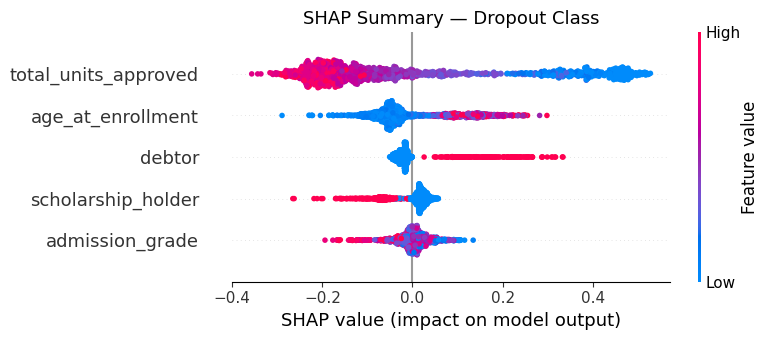

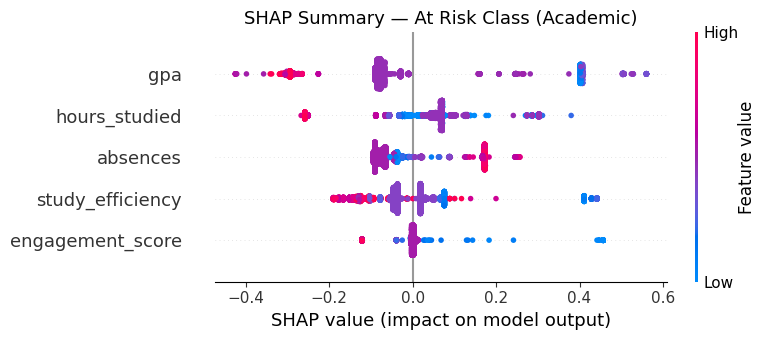

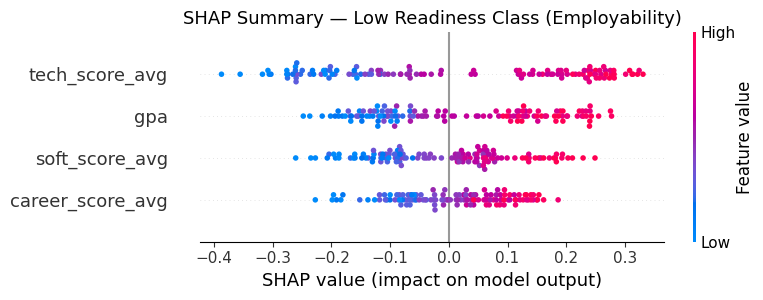

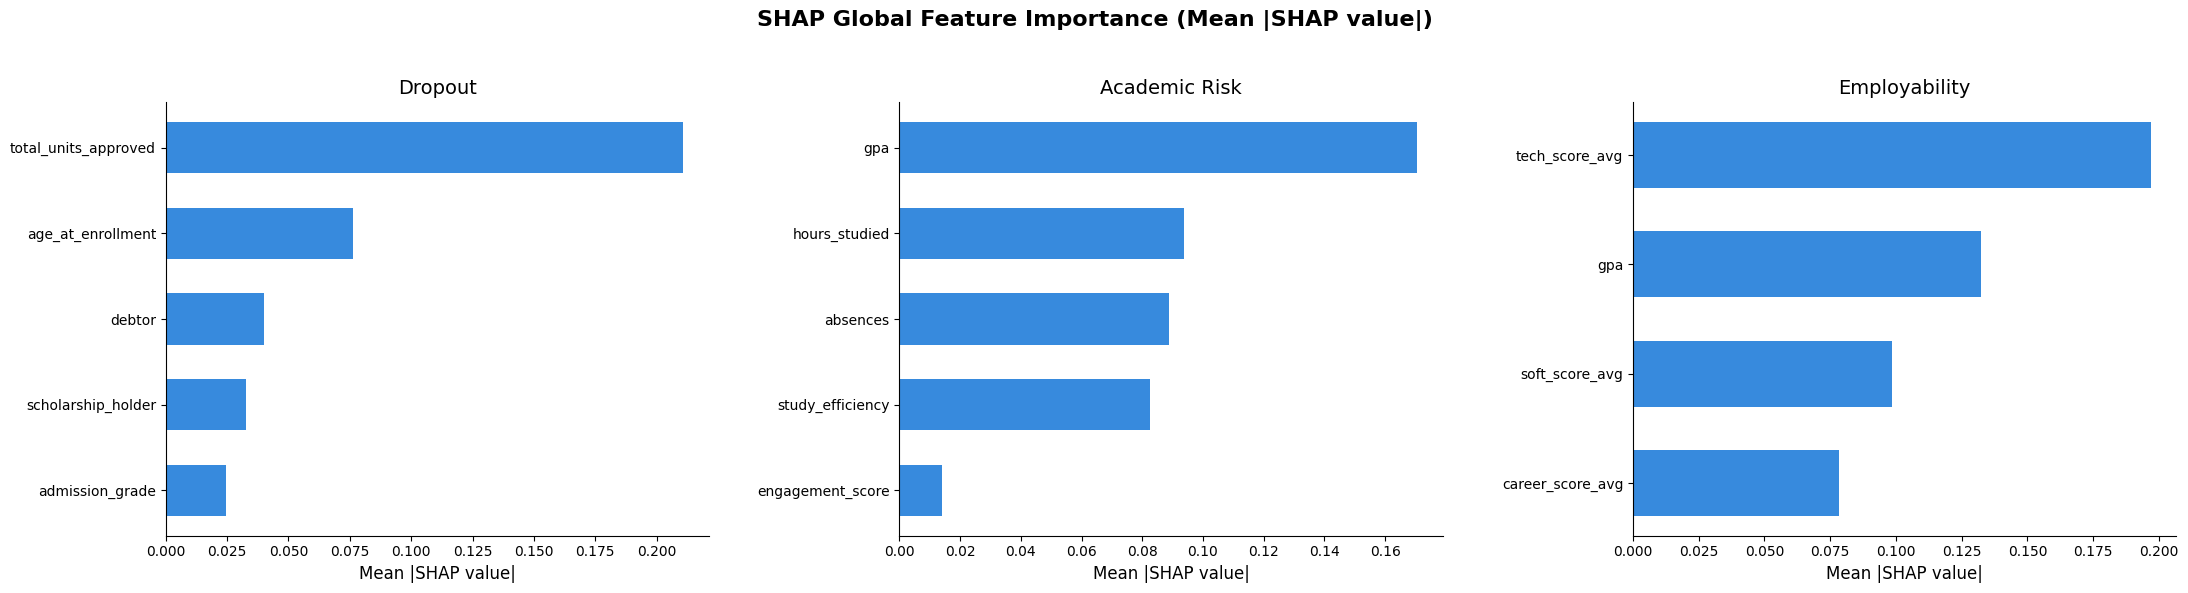

In [35]:
import shap
import numpy as np
import matplotlib.pyplot as plt

def get_class_shap(shap_vals, class_index=0):
    """Safely extracts a 2D array of SHAP values for a specific class, 
    handling both old (list) and new (3D array) SHAP formats."""
    if isinstance(shap_vals, list):
        return shap_vals[class_index]
    elif len(shap_vals.shape) == 3:
        return shap_vals[:, :, class_index]
    else:
        return shap_vals

# 1. SHAP Dropout (Using Random Forest)
explainer_drop = shap.TreeExplainer(rf_drop)
shap_vals_drop = explainer_drop.shap_values(X_test_d)
shap_drop_class = get_class_shap(shap_vals_drop, 0)

plt.figure()
shap.summary_plot(shap_drop_class, X_test_d, feature_names=DROPOUT_FEATURES, show=False)
plt.title("SHAP Summary — Dropout Class", fontsize=13)
plt.tight_layout()
plt.savefig('outputs/shap_dropout_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. SHAP Academic (Using Random Forest)
explainer_acad = shap.TreeExplainer(rf_acad)
shap_vals_acad = explainer_acad.shap_values(X_test_a)
shap_acad_class = get_class_shap(shap_vals_acad, 0)

plt.figure()
shap.summary_plot(shap_acad_class, X_test_a, feature_names=ACADEMIC_FEATURES, show=False)
plt.title("SHAP Summary — At Risk Class (Academic)", fontsize=13)
plt.tight_layout()
plt.savefig('outputs/shap_academic_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. SHAP employability (Using Random Forest)
explainer_emp = shap.TreeExplainer(rf_emp)
shap_vals_emp = explainer_emp.shap_values(X_test_e)
shap_emp_class = get_class_shap(shap_vals_emp, 0)

plt.figure()
shap.summary_plot(shap_emp_class, X_test_e, feature_names=EMPLOY_FEATURES, show=False)
plt.title("SHAP Summary — Low Readiness Class (Employability)", fontsize=13)
plt.tight_layout()
plt.savefig('outputs/shap_employ_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. SHAP Global Bar Chart 
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('SHAP Global Feature Importance (Mean |SHAP value|)', fontsize=16, fontweight='bold')

for (title, shap_arr, features, ax) in [
    ('Dropout',       shap_drop_class, DROPOUT_FEATURES,  axes[0]),
    ('Academic Risk', shap_acad_class, ACADEMIC_FEATURES, axes[1]),
    ('Employability', shap_emp_class,  EMPLOY_FEATURES,   axes[2]),
]:
    mean_abs = np.abs(shap_arr).mean(axis=0)
    idx = np.argsort(mean_abs)
    ax.barh([features[i] for i in idx], mean_abs[idx], color=PALETTE[0], edgecolor='none', height=0.6)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Mean |SHAP value|')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(wspace=0.35) 
plt.savefig('outputs/shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()


<Figure size 1000x500 with 0 Axes>

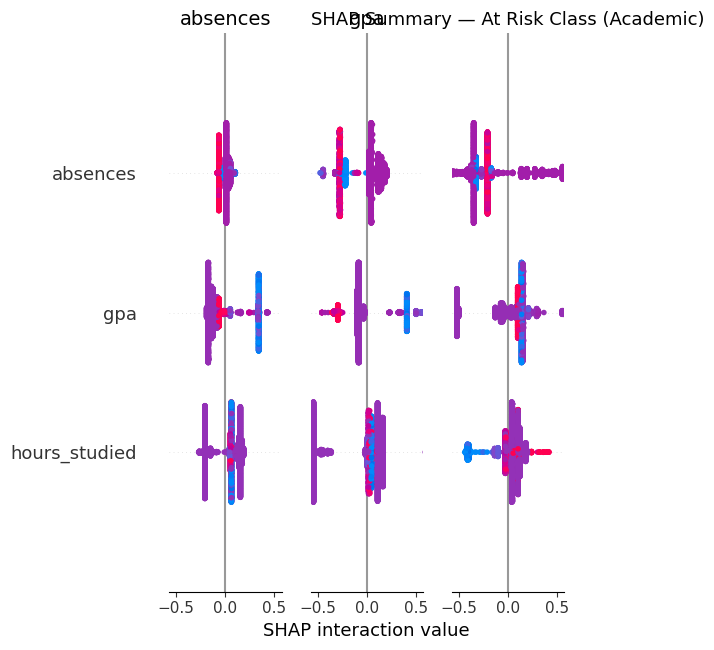

In [36]:
#SHAP Academic 
explainer_acad = shap.TreeExplainer(rscv_acad.best_estimator_)
shap_vals_acad = explainer_acad.shap_values(X_test_a)
shap_acad_class = shap_vals_acad[0] if isinstance(shap_vals_acad, list) else shap_vals_acad

plt.figure()
shap.summary_plot(shap_acad_class, X_test_a, feature_names=ACADEMIC_FEATURES, show=False)
plt.title("SHAP Summary — At Risk Class (Academic)", fontsize=13)
plt.tight_layout()
plt.savefig('outputs/shap_academic_summary.png', dpi=150, bbox_inches='tight')
plt.show()


<Figure size 1000x500 with 0 Axes>

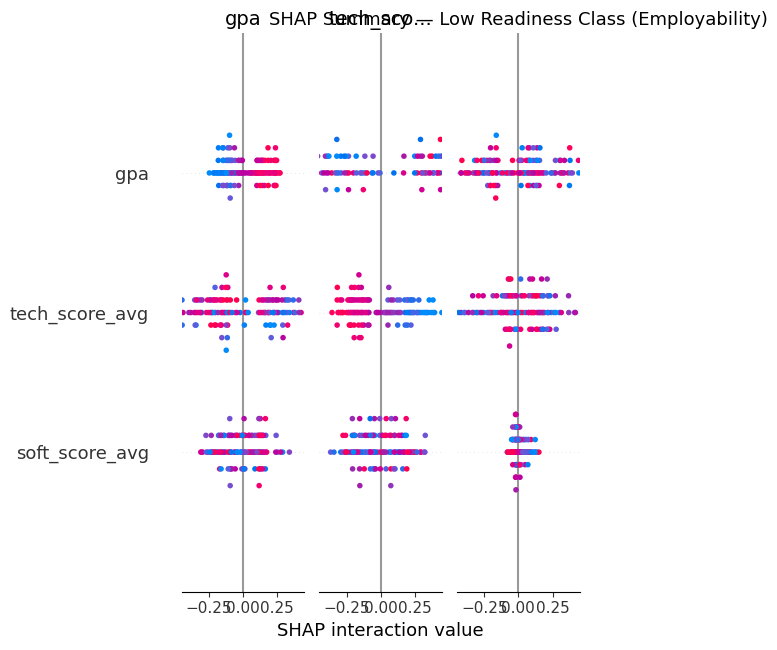

In [37]:
#SHAP employability 
explainer_emp = shap.TreeExplainer(rscv_emp.best_estimator_)
shap_vals_emp = explainer_emp.shap_values(X_test_e)
shap_emp_class = shap_vals_emp[0] if isinstance(shap_vals_emp, list) else shap_vals_emp

plt.figure()
shap.summary_plot(shap_emp_class, X_test_e, feature_names=EMPLOY_FEATURES, show=False)
plt.title("SHAP Summary — Low Readiness Class (Employability)", fontsize=13)
plt.tight_layout()
plt.savefig('outputs/shap_employ_summary.png', dpi=150, bbox_inches='tight')
plt.show()


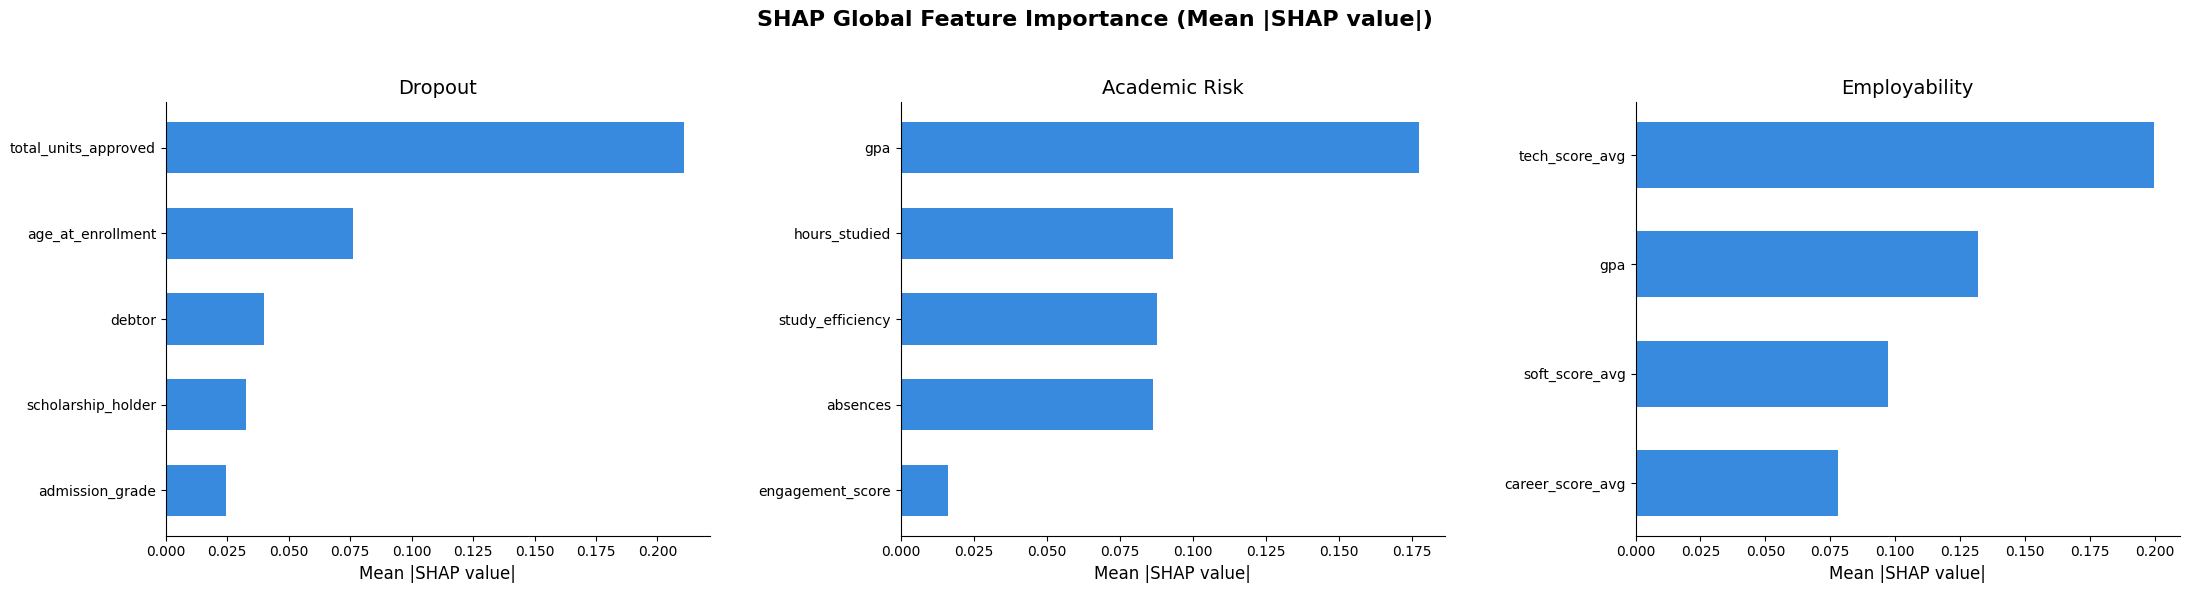

In [38]:
# SHAP Global Bar Chart 
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('SHAP Global Feature Importance (Mean |SHAP value|)', fontsize=16, fontweight='bold')

for (title, shap_arr, features, ax) in [
    ('Dropout',       shap_drop_class, DROPOUT_FEATURES,  axes[0]),
    ('Academic Risk', shap_acad_class, ACADEMIC_FEATURES, axes[1]),
    ('Employability', shap_emp_class,  EMPLOY_FEATURES,   axes[2]),
]:
    # --- SAFETY FIX: Force the array to be 2D regardless of what is in memory ---
    if isinstance(shap_arr, list):
        current_shap = shap_arr[0]
    elif hasattr(shap_arr, 'shape') and len(shap_arr.shape) == 3:
        current_shap = shap_arr[:, :, 0]
    else:
        current_shap = shap_arr
    # --------------------------------------------------------------------------
        
    mean_abs = np.abs(current_shap).mean(axis=0)
    idx = np.argsort(mean_abs)
    
    # Cast to a pure list of strings to prevent index errors
    feature_list = [str(features[i]) for i in idx]
    
    ax.barh(feature_list, mean_abs[idx], color=PALETTE[0], edgecolor='none', height=0.6)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Mean |SHAP value|')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(wspace=0.35) 
plt.savefig('outputs/shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()


 ## FINAL EVALUATION & PROJECT CONCLUSIONS ##

Project Deliverables Checklist & Objectives Review
At the beginning of this Capstone, we set out to build a comprehensive, multi-layered AI system. Here is our final evaluation:

**Objective**

**1. Build a classification model to predict student academic outcomes.**

Successfully implemented. Using our Dropout Dataset, we trained Random Forest and XGBoost classifiers that accurately distinguish between Dropouts and Graduates, proving that early academic momentum and financial stability are the ultimate anchors for university retention.

**2. Develop an employability assessment.**

Successfully implemented. Using both our Employability and Resume NLP datasets, our classifiers accurately categorize students into professional readiness levels (Low, Medium and High). We proved that technical and soft skills heavily outweigh baseline GPA when determining job market readiness.  

**3. Identify the key demographic and academic features that drive student risk.**

Successfully implemented. By integrating SHAP Game Theory alongside our EDA correlation heat maps, we successfully broke open the AI's "black box." We mathematically identified that demographic features (Age at Enrollment, Debtor Status) and academic features (1st Semester Units Approved, GPA, Hours Studied) are the absolute highest, quantifiable drivers of student risk.

**4. Create a user-friendly interface for real-time prediction and decision-making.**

The trained models generated in this notebook are fully optimized and saved. The final step of this project is to deploy them into a local Streamlit web application, allowing academic advisors and career counselors to run live, real-time inferences on new students.

### Final Answers to Key Business Questions ###

We can now definitively answer the Key Questions posed using our four distinct datasets:

**1.	What are the most significant predictors of student dropout?**

Based on our SHAP analysis, the most powerful predictor of dropout is a lack of academic momentum (low total_units_approved). Secondary drivers are demographic (age_at_enrollment) and financial (debtor status).

**2.	How do daily behaviors impact Academic Risk mid-semester?**

Exceptionally strongly. Our models confirmed that while historical GPA is a strong baseline, behavioral metrics like high absences and low hours_studied act as massive multipliers for academic risk.

**3.	How strongly do first-semester academic grades correlate with final graduation?**

Exceptionally strongly. Our SHAP analysis proved that first-semester academic momentum (specifically total_units_approved and admission_grade) is the single largest anchor keeping a student enrolled. Failing to secure passing grades in the first semester pushes the AI's risk-prediction model heavily toward "Dropout." This proves that intervention must happen during the first 6 months, not the second year.

**4. What impact do financial factors (scholarships and debt) have on student success?**

They act as powerful opposing forces. Having active debt strongly pushes the model to predict a "Dropout", while being a scholarship_holder acts as a heavy protective weight, anchoring the prediction toward "Graduate".

**5.	Can we accurately predict a student's employability level?**

 Yes. Our modeling proves that employability is highly predictable. Furthermore, our analysis revealed that while a high GPA is important, tech_score_avg (Technical Skills) is actually the number one driver for achieving a "High Readiness" employability classification. By combining this with our Resume NLP model, we can accurately assess both the student's skill levels and their market fit.


## Final Conclusions: A Holistic Student Lifecycle AI ##

This project successfully proves that student risk and employability are not random occurrences, but highly predictable outcomes driven by quantifiable metrics across a student's entire lifecycle. 

By utilizing four distinct datasets, we built a comprehensive pipeline:

1. `Enrollment Phase`: Predicting early dropout risk based on demographics and finances.
2. `Mid-Degree Phase`: Tracking behavioral risk based on attendance and study habits.
3. `Pre-Graduation Phase`: Assessing job-market readiness based on hard/soft skills.
4. `Placement Phase`: Using NLP to analyze resumes and categorize industry fit.

By leveraging Machine Learning and NLP, universities can move away from reactive counseling and build a Proactive, Holistic Intervention System.


 ## Strategic Recommendations & Future Steps ##

**For University Administration & Career Services:**

1. **Early Warning System**: Integrate the Dropout and Academic Risk models into the university portal. If a student triggers the financial risk model early, or the behavioral risk model mid-semester, advisors should automatically be notified to intervene.

2. **Curriculum Updates**: Since technical skills heavily outweigh general GPA for job readiness, career services should push heavily for mandatory technical workshops before the senior year.

3. **Automated Resume Audits**: Utilize the NLP model to automatically scan student resumes submitted to the career center, instantly flagging resumes that lack the keyword density required for their target job category.

### Future Technical Steps: ###

1. **Streamlit Deployment**: Wrap the best-performing models into an interactive, user-friendly Streamlit dashboard so non-technical advisors can input student data and get live predictions.

2. **Integration into University Systems**: Our ultimate goal is to remove the need for manual data entry. By building a REST API using Flask, the university's main student database (e.g. Canvas) can automatically send daily student data directly to our predictive models in the cloud, generating automated risk reports for the administration in real-time.
